# Formula 1 Race Winners Analysis (1950-2025)
## A Comprehensive Analysis of F1 History Through Race Winners

---

***Data Preparation***

In [1]:
import pandas as pd

data=pd.read_csv("winners_f1_1950_2025_v2.csv")

data.head()

,date,continent,grand_prix,circuit,winner_name,team,time,laps,year
0,1950-05-13,Europe,Great Britain,Silverstone Circuit,Nino Farina,Alfa Romeo,02:13:23,70.0,1950
1,1950-05-21,Europe,Monaco,Circuit de Monaco,Juan Manuel Fangio,Alfa Romeo,03:13:18,100.0,1950
2,1950-05-30,North America,United States,Indianapolis Motor Speedway,Johnnie Parsons,Kurtis Kraft Offenhauser,02:46:55,138.0,1950
3,1950-06-04,Europe,Switzerland,Circuit Bremgarten,Nino Farina,Alfa Romeo,02:02:53,42.0,1950
4,1950-06-18,Europe,Belgium,Circuit de Spa Francorchamps,Juan Manuel Fangio,Alfa Romeo,02:47:26,35.0,1950


Loading and examining the F1 winners dataset

*Inspect dataset structure and missing values*

In [2]:
data.shape

(1142, 9)

It shows that the dataset contains 1142 rows and 9 columns

In [3]:
data.isnull().sum()

date           0
continent      0
grand_prix     0
circuit        0
winner_name    0
team           0
time           0
laps           0
year           0
dtype: int64

Since the dataset doesnt include any null values, it does not require any imputation.

*Create time-based features (decade, month)*

In [4]:
data['date']=pd.to_datetime(data['date'])

data['month']=data['date'].dt.month

data['decade']=(data['year'] //10 )*10

data.head(10)

,date,continent,grand_prix,circuit,winner_name,team,time,laps,year,month,decade
0,1950-05-13,Europe,Great Britain,Silverstone Circuit,Nino Farina,Alfa Romeo,02:13:23,70.0,1950,5,1950
1,1950-05-21,Europe,Monaco,Circuit de Monaco,Juan Manuel Fangio,Alfa Romeo,03:13:18,100.0,1950,5,1950
2,1950-05-30,North America,United States,Indianapolis Motor Speedway,Johnnie Parsons,Kurtis Kraft Offenhauser,02:46:55,138.0,1950,5,1950
3,1950-06-04,Europe,Switzerland,Circuit Bremgarten,Nino Farina,Alfa Romeo,02:02:53,42.0,1950,6,1950
4,1950-06-18,Europe,Belgium,Circuit de Spa Francorchamps,Juan Manuel Fangio,Alfa Romeo,02:47:26,35.0,1950,6,1950
5,1950-07-02,Europe,France,Circuit de Reims Gueux,Juan Manuel Fangio,Alfa Romeo,02:57:52,64.0,1950,7,1950
6,1950-09-03,Europe,Italy,Autodromo Nazionale di Monza,Nino Farina,Alfa Romeo,02:51:17,80.0,1950,9,1950
7,1951-05-27,Europe,Switzerland,Circuit Bremgarten,Juan Manuel Fangio,Alfa Romeo,02:07:53,42.0,1951,5,1950
8,1951-05-30,North America,United States,Indianapolis Motor Speedway,Lee Wallard,Kurtis Kraft Offenhauser,03:57:38,200.0,1951,5,1950
9,1951-06-17,Europe,Belgium,Circuit de Spa Francorchamps,Nino Farina,Alfa Romeo,02:45:46,36.0,1951,6,1950


One of the important things to do when we have a date column is to make sure that the values of it are in date format and are not string.
To create the 'month' column, we firstly need to have a date column in date format.
And to create the 'decade' column we can use the 'year' column that alredy exists.

***Dataset Scope & Growth***

*What is the total number of races in the dataset?*

In [5]:
data.shape[0]

1142

the number of races is equal to the number of rows in this dataset.Because each row shows one race with one winner.

*How has the number of races per season changed over time?*

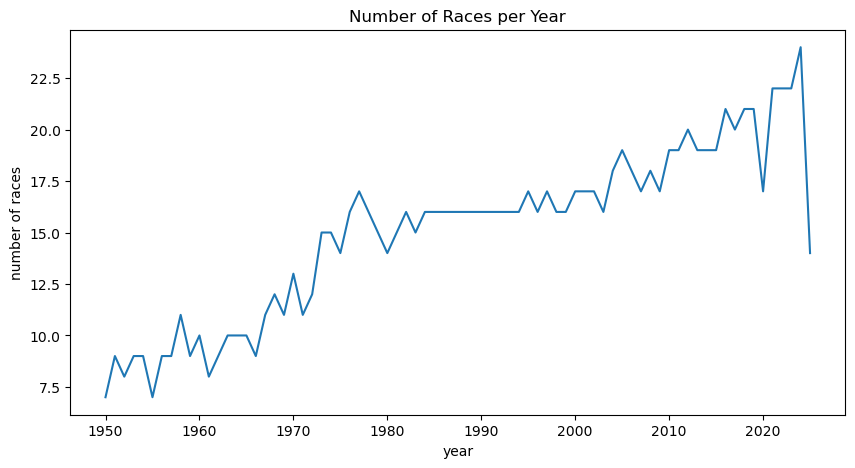

In [6]:
from matplotlib import pyplot as plt

race_counts = data.groupby('year').size()

x=race_counts.index
y=race_counts.values

plt.figure(figsize=(10, 5))
plt.plot(x,y)
plt.title("Number of Races per Year")
plt.xlabel("year")
plt.ylabel("number of races")
plt.show()


In Formula 1, each season corresponds to a single year. And according to the plot above, the number of races per season has increased over time.

***Driver Success Analysis***

*Who are the top winning drivers in Formula 1 history?*

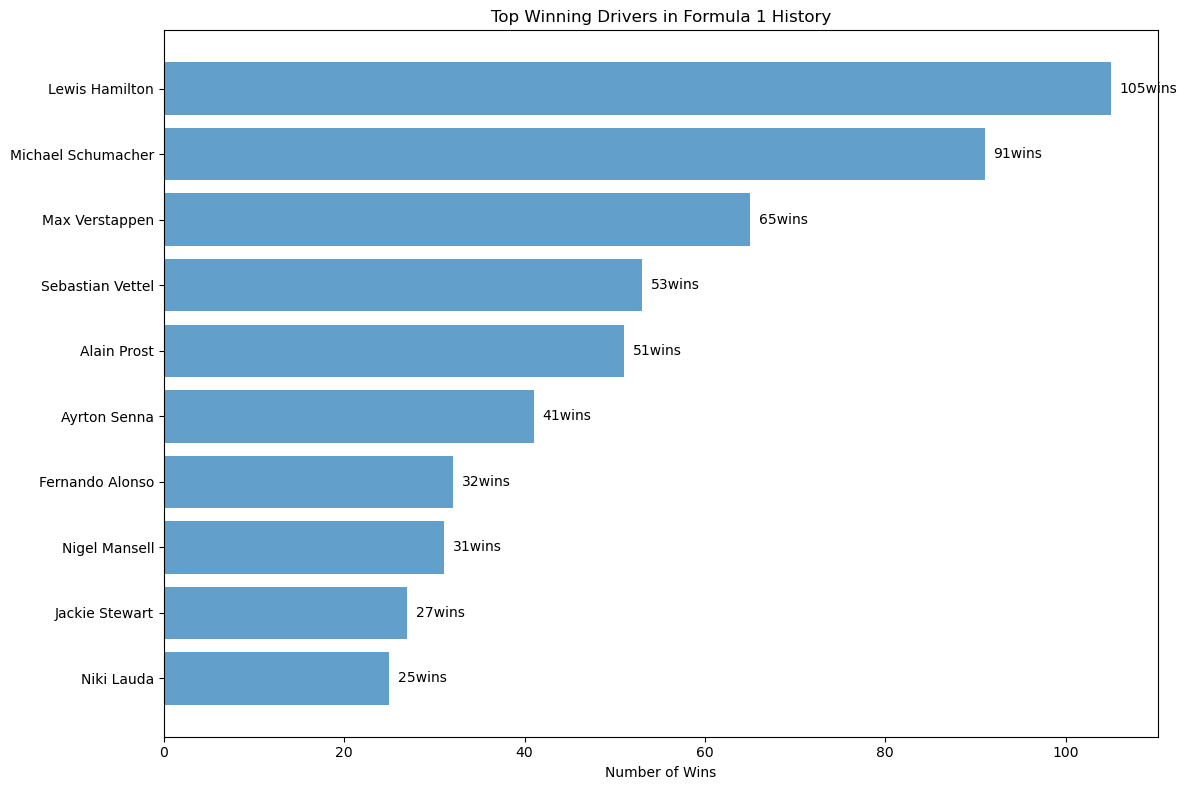

In [7]:
top_drivers=data['winner_name'].value_counts().head(10)


plt.figure(figsize=(12, 8))
bars= plt.barh(range(len(top_drivers)) , top_drivers.values, alpha=0.7)


plt.yticks(range(len(top_drivers)), top_drivers.index)
plt.xlabel('Number of Wins')
plt.title('Top Winning Drivers in Formula 1 History')
plt.gca().invert_yaxis()


for i, (bar, val) in enumerate(zip(bars, top_drivers.values)):
    plt.text(val + 1, bar.get_y() + bar.get_height()/2,  f'{val}wins', va='center')

plt.tight_layout()
plt.show()



Lewis Hamilton with 105 wins - the most in F1 history!

*How is driver dominance distributed across decades?*

In [8]:
win_decade=data.groupby('decade')['winner_name'].value_counts()

win_decade=win_decade.reset_index(name='wins').sort_values( by=['decade','wins'], ascending=[True,False])

top_decade=win_decade.groupby('decade')

top_decade.head(1)


,decade,winner_name,wins
0,1950,Juan Manuel Fangio,24
24,1960,Jim Clark,25
45,1970,Niki Lauda,17
74,1980,Alain Prost,39
95,1990,Michael Schumacher,35
112,2000,Michael Schumacher,56
129,2010,Lewis Hamilton,73
141,2020,Max Verstappen,57


Driver dominance has shifted from a competitive, multi-champion environment in the 1970s to an increasingly concentrated landscape in recent decades. The 2020s, in particular, show unprecedented concentration with Verstappen winning nearly half of all races - a level of dominance unseen in F1 history.

***Team Performance Trends***

*Which constructor teams have the most total wins?*

In [9]:
total_win_team=data['team'].value_counts()
total_win_team.head()

team
Ferrari             249
Mercedes            121
McLaren Mercedes     85
Williams Renault     64
Lotus Ford           47
Name: count, dtype: int64

Ferrari's status is numerically confirmed with 249 wins - more than double the next closest competitor. This decades of competition demonstrates remarkable longevity and consistency at the highest level of motorsport.

*How does team dominance shift between decades?*

In [10]:
team_decade=data.groupby('decade')['team'].value_counts()

by_decade=team_decade.groupby('decade')

by_decade.head(1)


decade  team                      
1950    Ferrari                       30
1960    Lotus Climax                  24
1970    Ferrari                       37
1980    McLaren Honda                 25
1990    Williams Renault              61
2000    Ferrari                       85
2010    Mercedes                      93
2020    Red Bull Racing Honda RBPT    30
Name: count, dtype: int64

Ferrari's three distinct dominant eras (1950s, 1970s, 2000s) demonstrate their unique ability to reinvent themselves across generations, while the 2010s Mercedes dominance (93 wins) represents the most successful single-decade performance in F1 history.

***Geographic Evolution***

*Which continents host the most winning races?*

In [11]:
continent=data['continent'].value_counts()
continent

continent
Europe           686
Asia             163
North America    158
South America     72
Oceania           39
Africa            24
Name: count, dtype: int64

Europe remains the heartland of Formula 1, hosting more than 600 of all Grands Prix in history.

*How has Formula 1 expanded globally over time?*

In [12]:
race_continent_decade=data.groupby('decade')['continent'].value_counts()

race_continent_decade=race_continent_decade.reset_index(name='race_count')

race_continent_decade

,decade,continent,race_count
0,1950,Europe,68
1,1950,North America,11
2,1950,South America,7
3,1950,Africa,1
4,1960,Europe,72
5,1960,North America,21
6,1960,Africa,6
7,1960,South America,1
8,1970,Europe,94
9,1970,North America,24


F1 has transformed from a European-centric championship to a global spectacle, with Asia emerging as the second-most important market and the calendar now spanning five continents regularly.

***Race Structure & Characteristics***

*How have average race times changed across decades?*

In [13]:
data['time']=pd.to_timedelta(data['time'],errors='coerce')

time_per_decade=data.groupby('decade')['time'].mean().reset_index(name='avg') 

time_per_decade['avg'] = time_per_decade['avg'].dt.round('1s').astype(str).str.replace('0 days ', '', regex=False)

time_per_decade.head(8)

,decade,avg
0,1950,02:52:10
1,1960,02:12:36
2,1970,01:42:44
3,1980,01:38:09
4,1990,01:36:13
5,2000,01:32:22
6,2010,01:37:59
7,2020,01:37:34


Over the time, the average time of the race has decreased and has became shorter

*How has the number of laps evolved over seasons?*

In [14]:
laps_mean=data.groupby('year')['laps'].mean().reset_index(name='avg_lap')
laps_mean

,year,avg_lap
0,1950,75.571429
1,1951,76.888889
2,1952,81.000000
3,1953,81.777778
4,1954,80.222222
...,...,...
71,2021,58.954545
72,2022,58.818182
73,2023,60.227273
74,2024,60.166667


While total race distance has remained relatively constant (~305km), faster modern cars complete this distance in fewer laps on longer, purpose-built circuits compared to the shorter, more numerous laps on historic road courses.

***Long-Term Trends***

*How many wins occur per year?*

In [15]:
win_per_year=data.groupby('year').size().reset_index(name='wins per year')
win_per_year

,year,wins per year
0,1950,7
1,1951,9
2,1952,8
3,1953,9
4,1954,9
...,...,...
71,2021,22
72,2022,22
73,2023,22
74,2024,24


It shows that the number of races or games is increasing over time and more races are happening than before.

***Performance Concentration***

*What is each driver’s winning probability per decade?*

In [16]:
wins_per_driver_decade= data.groupby(['decade', 'winner_name']).size()
# wins_per_driver_decade

total_races_per_decade =data.groupby('decade').size()
# total_races_per_decade

winning_probability=(wins_per_driver_decade /wins_per_driver_decade.index.get_level_values(0).map(total_races_per_decade)).reset_index(name='win_prob')

winning_probability['win_prob']=(winning_probability['win_prob'].round(3) )* 100
winning_probability


,decade,winner_name,win_prob
0,1950,Alberto Ascari,14.9
1,1950,Bill Vukovich,2.3
2,1950,Bob Sweikert,1.1
3,1950,Bruce McLaren,1.1
4,1950,Jack Brabham,2.3
...,...,...,...
148,2020,Max Verstappen,47.1
149,2020,Oscar Piastri,6.6
150,2020,Pierre Gasly,0.8
151,2020,Sergio Perez,5.0


This analysis calculates each driver's win probability within a given decade, revealing patterns of dominance and competitiveness across eras.Max Verstappen's 47.1% win probability in the 2020s means he wins nearly 1 out of every 2 races he enters.

*Which decades were most dominated by a small group of drivers?*

In [17]:
WP= winning_probability.copy()  


domination=(
    WP
    .sort_values(['decade', 'win_prob'], ascending=[True, False])
    .groupby('decade', as_index=False)
    .head(3)  
    .groupby('decade', as_index=False)['win_prob']
    .sum()   
    .rename(columns={'win_prob': 'top3_win_share'})
    .sort_values('top3_win_share', ascending=False))

domination


,decade,top3_win_share
6,2010,72.7
7,2020,71.9
0,1950,56.3
5,2000,54.6
3,1980,50.6
1,1960,50.0
4,1990,48.2
2,1970,32.6


2010 and 2020 were more dominated by top three winners with more than 70%